<a href="https://colab.research.google.com/github/Kushtylish/BUMVO_95-STRATEGY/blob/main/BUMVO_95/Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📂 Loading XAUUSD data...
📂 Please upload your XAUUSD CSV file:


Saving XAU_USD Historical Data (4).csv to XAU_USD Historical Data (4) (1).csv
✅ Loaded 1593 days of data.
   Period: 2020-01-01 00:00:00 to 2026-02-12 00:00:00
📈 Returns series: 1592 days

BUMVO_95 for XAUUSD – HYBRID TREND STRATEGY

📊 Using fixed percentile = 95

🚀 Final optimisation with percentile = 95


   Best: L=72, method=fixed, pct_val=72.891

✅ Optimal parameters:
   Lookback L:        72 days
   Position sizing:   fixed
   Percentile (α):    95
   Lot scale:         1.50x
   Spread cost:       0.0200%
   L=72, fixed:
     % non‑zero signals: 75.94%
     Number of trades: 8
     Mean PnL: 0.002515
     Sharpe: 1.966

--- Out‑of‑sample performance (test set) ---
   Annualised Sharpe: 1.966
   Total return:      108.05%
   Max drawdown:      -20.08%


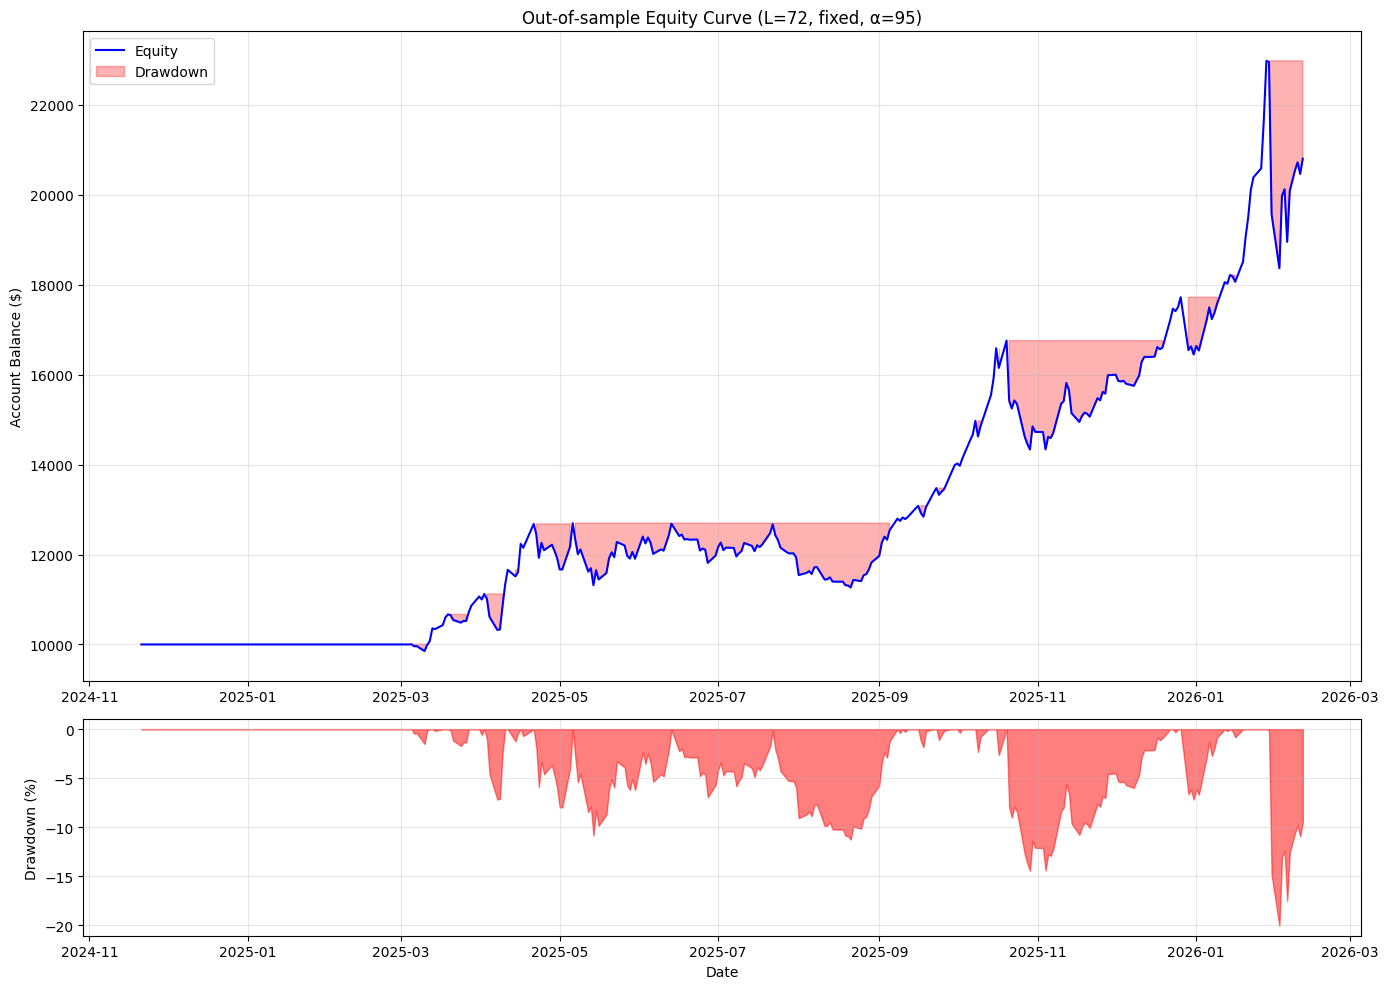


📈 Equity Summary:
   Starting balance: $10,000.00
   Ending balance:   $20,804.73
   Total return:     108.05%
   Max drawdown:     -20.08%

🎲 Monte Carlo Drawdown Simulation (1000 scenarios)


Monte Carlo: 100%|██████████| 1000/1000 [00:10<00:00, 97.65it/s]


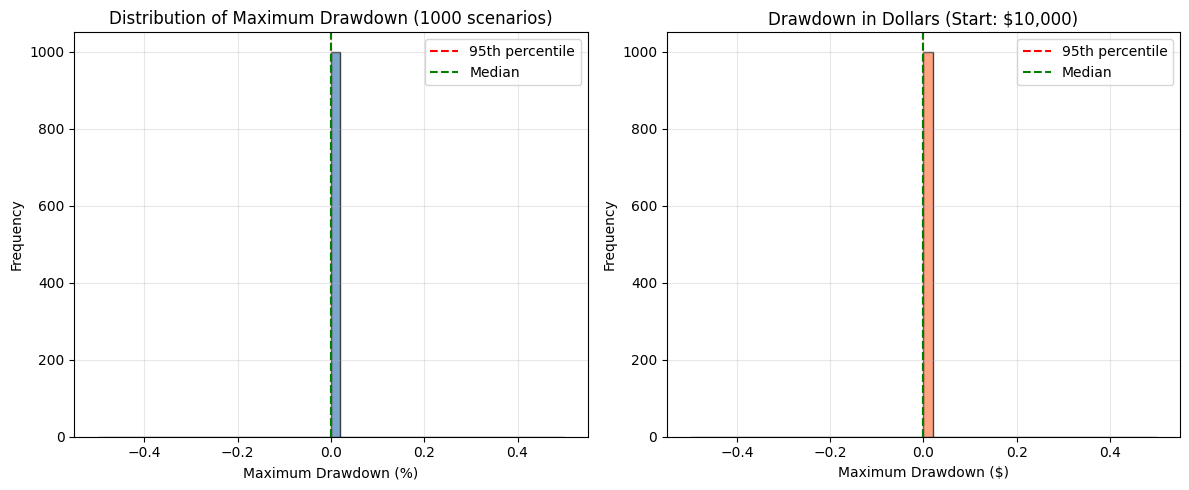


📊 Monte Carlo Drawdown Statistics:
   Median max drawdown:      0.00%
   95th percentile:          0.00%
   Worst drawdown in sims:   0.00%
   Median $ drawdown:        $0
   95th percentile $:        $0


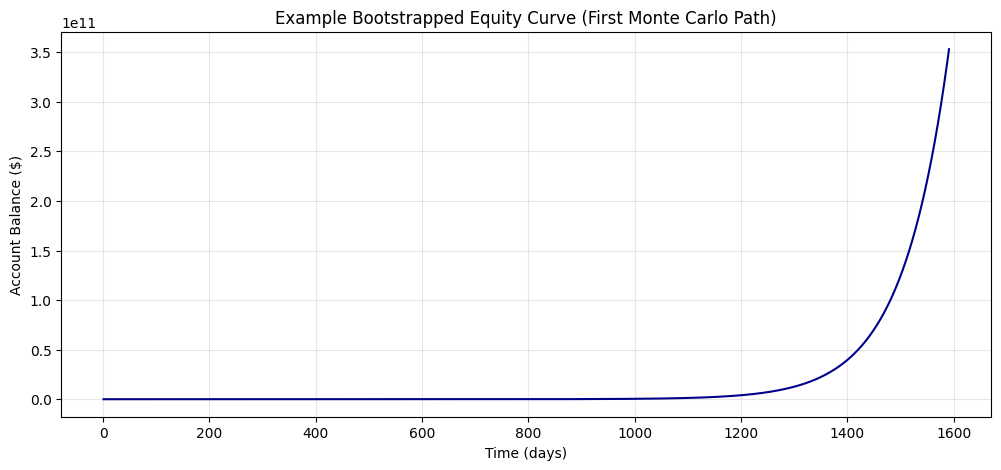


✅ Analysis complete.


In [6]:
# -*- coding: utf-8 -*-
"""
BUMVO_95 for XAUUSD – HYBRID TREND STRATEGY
COMPLETE FIXED VERSION – WITH LOT SCALE (1.5x) AND REALISTIC SPREAD (0.02%)
"""

import os
import numpy as np
import pandas as pd
from arch.bootstrap import StationaryBootstrap
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# SET CSV_PATH = None for Colab upload
# ------------------------------------------------------------
CSV_PATH = None   # <-- CHANGE to None for Colab upload, or provide full path

# ------------------------------------------------------------
# ROBUST CSV LOADER – auto date format, comma cleaning
# ------------------------------------------------------------
def load_xauusd_csv(filepath=None):
    """
    Load XAUUSD CSV with robust date parsing and price cleaning.
    Returns pandas Series of daily closing prices (DatetimeIndex).
    """
    # ----- Load file (path or upload) -----
    if filepath and os.path.exists(filepath):
        print(f"📂 Loading from: {filepath}")
        df = pd.read_csv(filepath)
    else:
        try:
            from google.colab import files
            IN_COLAB = True
        except ImportError:
            IN_COLAB = False

        if IN_COLAB:
            print("📂 Please upload your XAUUSD CSV file:")
            uploaded = files.upload()
            if not uploaded:
                raise FileNotFoundError("No file uploaded.")
            filename = next(iter(uploaded))
            df = pd.read_csv(filename)
        else:
            raise FileNotFoundError(f"❌ File not found: {filepath}")

    # ----- Auto‑detect date column -----
    date_col = None
    for col in df.columns:
        if 'date' in col.lower():
            date_col = col
            break
    if date_col is None:
        raise ValueError("No date column found.")

    # ----- Parse dates (no format assumption) -----
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col])
    df = df.sort_values(date_col)

    # ----- Auto‑detect price column -----
    price_col = None
    for col in df.columns:
        if col.lower() in ['price', 'close', 'adj close']:
            price_col = col
            break
    if price_col is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            price_col = numeric_cols[0]
        else:
            for col in df.columns:
                if col != date_col:
                    try:
                        cleaned = df[col].astype(str).str.replace(',', '').str.replace(' ', '')
                        pd.to_numeric(cleaned, errors='raise')
                        price_col = col
                        break
                    except:
                        continue
            if price_col is None:
                raise ValueError("No price column found.")

    # ----- Clean price column: remove commas, spaces, convert to float -----
    df[price_col] = df[price_col].astype(str).str.replace(',', '', regex=False)
    df[price_col] = df[price_col].str.replace(' ', '', regex=False)
    df[price_col] = pd.to_numeric(df[price_col], errors='coerce')
    df = df.dropna(subset=[price_col])

    # ----- Create Series with DatetimeIndex -----
    prices = df.set_index(date_col)[price_col]
    return prices

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
print("📂 Loading XAUUSD data...")
prices = load_xauusd_csv(CSV_PATH)
print(f"✅ Loaded {len(prices)} days of data.")
print(f"   Period: {prices.index[0]} to {prices.index[-1]}")

# Use last 3000 days (or all if less)
if len(prices) > 3000:
    prices = prices.iloc[-3000:]
    print(f"   Using last 3000 days: {prices.index[0]} to {prices.index[-1]}")

# Returns: length = len(prices) - 1
returns = prices.pct_change().dropna()
print(f"📈 Returns series: {len(returns)} days")

# ------------------------------------------------------------
# STRATEGY PARAMETERS – MODIFY THESE AS NEEDED
# ------------------------------------------------------------
SPREAD = 0.0002          # 0.02% per trade (approx 2 pips at $2600/oz)
INITIAL_CAPITAL = 10000.0
LOT_SCALE = 1.5          # 150% of capital (1.5x leverage)

# ------------------------------------------------------------
# DEPENDENT BOOTSTRAP (Stationary Bootstrap)
# ------------------------------------------------------------
def bootstrap_returns(returns, n_bootstrap=500, block_size=10):
    """Generate stationary bootstrap samples of return series."""
    bs = StationaryBootstrap(block_size, returns, seed=42)
    boot_samples = []
    for data in bs.bootstrap(n_bootstrap):
        idx = data[0][0]                     # 1D numpy array of indices
        idx = np.asarray(idx).ravel().astype(int)
        boot_samples.append(returns.iloc[idx].values.ravel())
    return boot_samples

# ------------------------------------------------------------
# STRATEGY COMPONENTS
# ------------------------------------------------------------
def tsmom_signal(close, L):
    ret = np.log(close / close.shift(L))
    return np.sign(ret)

def ma_signal(close, fast=50, slow=200):
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    diff = ema_fast - ema_slow
    return np.sign(diff)

def keltner_signal(close, period=20, mult=2.0):
    ema = close.ewm(span=period, adjust=False).mean()
    tr = np.maximum(
        close - close.shift(1),
        np.maximum(
            close.shift(1) - close,
            (close - close.shift(1)).abs()
        )
    ).abs()
    atr = tr.rolling(window=period).mean()
    upper = ema + mult * atr
    lower = ema - mult * atr
    signal = pd.Series(0, index=close.index)
    signal[close > upper] = 1
    signal[close < lower] = -1
    return signal

def combined_signal(close, L, ma_fast=50, ma_slow=200, keltner_period=20, keltner_mult=2.0):
    sig1 = tsmom_signal(close, L)
    sig2 = ma_signal(close, ma_fast, ma_slow)
    sig3 = keltner_signal(close, keltner_period, keltner_mult)
    net = sig1 + sig2 + sig3
    return np.sign(net).fillna(0)

def kelly_fraction(returns, window=252, rf=0.0):
    rolling_mean = returns.rolling(window, min_periods=window//2).mean()
    rolling_var = returns.rolling(window, min_periods=window//2).var()
    kelly = (rolling_mean - rf) / rolling_var
    return kelly.clip(-1.0, 1.0)

# ------------------------------------------------------------
# STRATEGY SIMULATION – WITH LOT SCALE & SAFE ALIGNMENT
# ------------------------------------------------------------
def simulate_strategy(returns, prices, L, pos_sizing='fixed',
                      ma_fast=50, ma_slow=200,
                      keltner_period=20, keltner_mult=2.0,
                      spread=SPREAD, lot_scale=LOT_SCALE, verbose=False):
    """
    returns : pandas Series of daily returns (DatetimeIndex)
    prices  : pandas Series of daily prices (DatetimeIndex, length = len(returns)+1)
    """
    # Ensure both are Series
    if isinstance(prices, pd.DataFrame):
        prices = prices.iloc[:, 0]

    # Generate combined signal (uses price series)
    signal = combined_signal(prices, L, ma_fast, ma_slow, keltner_period, keltner_mult)

    # Position sizing with LOT_SCALE
    if pos_sizing == 'fixed':
        position = signal * lot_scale
    elif pos_sizing == 'kelly':
        kelly = kelly_fraction(returns, window=252).fillna(0)
        position = signal * kelly * lot_scale
    else:
        raise ValueError("pos_sizing must be 'fixed' or 'kelly'")

    # Shift position to next day, fill initial NaNs with 0
    position = position.shift(1).fillna(0)

    # --- SAFE ALIGNMENT: slice to match returns length (works for any index type) ---
    position = position.iloc[:len(returns)]

    # Daily PnL (fraction of capital)
    pnl = position * returns

    # Transaction costs (spread) – charged on absolute change in position
    position_change = position.diff().abs()
    cost = spread * position_change
    pnl = pnl - cost

    # Drop any remaining NaNs (should only be at the very beginning)
    pnl = pnl.dropna()

    if len(pnl) == 0:
        return {'pnl': pd.Series(dtype=float), 'sharpe': 0.0, 'return': 0.0, 'max_dd': 0.0}

    # Performance metrics
    annual_factor = 252
    avg_return = pnl.mean() * annual_factor
    std_return = pnl.std() * np.sqrt(annual_factor)
    sharpe = avg_return / std_return if std_return > 0 else 0.0

    cum_return = (1 + pnl).prod() - 1
    cum = (1 + pnl).cumprod()
    running_max = cum.expanding().max()
    drawdown = (cum - running_max) / running_max
    max_dd = drawdown.min()

    # Optional diagnostics
    if verbose:
        trades = (position.diff().abs() > 0).sum()
        print(f"   L={L}, {pos_sizing}:")
        print(f"     % non‑zero signals: {(signal != 0).mean():.2%}")
        print(f"     Number of trades: {trades}")
        print(f"     Mean PnL: {pnl.mean():.6f}")
        print(f"     Sharpe: {sharpe:.3f}")

    return {
        'pnl': pnl,                # Series with DatetimeIndex
        'sharpe': sharpe,
        'return': cum_return,
        'max_dd': max_dd
    }

# ------------------------------------------------------------
# BOOTSTRAP OPTIMISATION (for a given percentile)
# ------------------------------------------------------------
def bootstrap_optimise(returns, prices, L_grid, pos_sizing_methods,
                       n_bootstrap=500, block_size=10, percentile=75, verbose=False):
    """For each (L, method), compute percentile of bootstrapped Sharpe ratios, return best."""
    if isinstance(prices, pd.DataFrame):
        prices = prices.iloc[:, 0]

    boot_returns_list = bootstrap_returns(returns, n_bootstrap, block_size)
    results = []

    for L in L_grid:
        for method in pos_sizing_methods:
            sharpes = []
            for boot_ret in tqdm(boot_returns_list, desc=f'L={L}, {method}', leave=False):
                boot_ret = np.asarray(boot_ret).ravel()
                # Reconstruct price series from bootstrapped returns
                start_price = prices.iloc[0]
                boot_price = start_price * np.exp(np.cumsum(boot_ret))
                # Use integer index (no date assumptions)
                boot_price = pd.Series(boot_price, index=np.arange(len(boot_ret)))
                # Convert returns to Series with same integer index
                boot_ret_series = pd.Series(boot_ret, index=np.arange(len(boot_ret)))
                perf = simulate_strategy(boot_ret_series, boot_price, L, pos_sizing=method, verbose=False)
                sharpes.append(perf['sharpe'])
            pct_val = np.percentile(sharpes, percentile)
            results.append({
                'L': L,
                'method': method,
                'percentile_value': pct_val,
                'sharpes': sharpes
            })

    best = max(results, key=lambda x: x['percentile_value'])
    if verbose:
        print(f"   Best: L={best['L']}, method={best['method']}, pct_val={best['percentile_value']:.3f}")
    return best['L'], best['method'], results

# ------------------------------------------------------------
# META‑OPTIMISATION – SKIPPED, USING FIXED 95TH PERCENTILE
# ------------------------------------------------------------
# (Function kept for reference but not used)
def select_percentile(returns, prices, L_grid, pos_sizing_methods,
                      n_bootstrap=200, block_size=10,
                      train_ratio=0.8, percentile_range=range(60,96,5)):
    pass

# ------------------------------------------------------------
# MONTE CARLO DRAWDOWN ANALYSIS
# ------------------------------------------------------------
def monte_carlo_drawdown(returns, prices, L, method, n_sim=1000, block_size=10,
                         initial_capital=10000.0):
    """Generate n_sim bootstrapped paths, compute max drawdown for each."""
    boot_samples = bootstrap_returns(returns, n_sim, block_size)
    max_dd_pct = []
    max_dd_dollar = []
    example_equity = None

    for i, boot_ret in enumerate(tqdm(boot_samples, desc="Monte Carlo")):
        boot_ret = np.asarray(boot_ret).ravel()
        start_price = prices.iloc[0]
        boot_price = start_price * np.exp(np.cumsum(boot_ret))
        boot_price = pd.Series(boot_price, index=np.arange(len(boot_ret)))
        boot_ret_series = pd.Series(boot_ret, index=np.arange(len(boot_ret)))
        perf = simulate_strategy(boot_ret_series, boot_price, L, pos_sizing=method, verbose=False)
        pnl = perf['pnl']
        if len(pnl) == 0:
            # If no trades, drawdown is 0
            max_dd_pct.append(0.0)
            max_dd_dollar.append(0.0)
            continue
        equity = initial_capital * (1 + pnl).cumprod()
        running_max = equity.expanding().max()
        drawdown = (equity - running_max) / running_max
        max_dd_pct.append(drawdown.min())
        max_dd_dollar.append((equity - running_max).min())
        if i == 0:
            example_equity = equity

    return {
        'max_dd_pct': np.array(max_dd_pct),
        'max_dd_dollar': np.array(max_dd_dollar),
        'example_equity': example_equity
    }

# ------------------------------------------------------------
# PLOTTING EQUITY CURVE
# ------------------------------------------------------------
def plot_equity_curve(pnl_series, title, initial_capital=10000.0):
    """Plot equity curve with drawdown shading."""
    equity = initial_capital * (1 + pnl_series).cumprod()
    running_max = equity.expanding().max()
    drawdown = (equity - running_max) / running_max

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(equity.index, equity, label='Equity', color='blue', linewidth=1.5)
    ax1.fill_between(equity.index, running_max, equity, where=(equity < running_max),
                      color='red', alpha=0.3, label='Drawdown')
    ax1.set_ylabel('Account Balance ($)')
    ax1.set_title(title)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.fill_between(drawdown.index, 0, drawdown * 100, color='red', alpha=0.5)
    ax2.set_ylabel('Drawdown (%)')
    ax2.set_xlabel('Date')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    final_balance = equity.iloc[-1]
    total_return = (final_balance / initial_capital - 1) * 100
    max_dd_pct = drawdown.min() * 100
    print(f"\n📈 Equity Summary:")
    print(f"   Starting balance: ${initial_capital:,.2f}")
    print(f"   Ending balance:   ${final_balance:,.2f}")
    print(f"   Total return:     {total_return:.2f}%")
    print(f"   Max drawdown:     {max_dd_pct:.2f}%")

    return equity, drawdown

# ------------------------------------------------------------
# MAIN EXECUTION
# ------------------------------------------------------------
def main():
    # Strategy hyperparameters grid
    L_grid = [72, 120, 168, 240, 360, 480, 720]
    pos_methods = ['fixed', 'kelly']
    n_bootstrap = 500
    block_size = 10

    global returns, prices

    print("\n" + "="*60)
    print("BUMVO_95 for XAUUSD – HYBRID TREND STRATEGY")
    print("="*60)

    # ----- Step 1: Use fixed 95th percentile (BUMVO_95) -----
    best_pct = 95
    print(f"\n📊 Using fixed percentile = {best_pct}")

    # ----- Step 2: Final optimisation on full data with chosen percentile -----
    print(f"\n🚀 Final optimisation with percentile = {best_pct}")
    final_L, final_method, _ = bootstrap_optimise(
        returns, prices, L_grid, pos_methods,
        n_bootstrap=n_bootstrap, block_size=block_size, percentile=best_pct, verbose=True
    )

    print(f"\n✅ Optimal parameters:")
    print(f"   Lookback L:        {final_L} days")
    print(f"   Position sizing:   {final_method}")
    print(f"   Percentile (α):    {best_pct}")
    print(f"   Lot scale:         {LOT_SCALE:.2f}x")
    print(f"   Spread cost:       {SPREAD*100:.4f}%")

    # ----- Step 3: Out‑of‑sample performance & equity curve -----
    split_idx = int(len(returns) * 0.8)
    test_ret = returns.iloc[split_idx:]
    test_price = prices.iloc[split_idx:]

    perf_test = simulate_strategy(test_ret, test_price, final_L, pos_sizing=final_method, verbose=True)
    pnl_series = perf_test['pnl']          # Series with DatetimeIndex

    print("\n--- Out‑of‑sample performance (test set) ---")
    print(f"   Annualised Sharpe: {perf_test['sharpe']:.3f}")
    print(f"   Total return:      {perf_test['return']*100:.2f}%")
    print(f"   Max drawdown:      {perf_test['max_dd']*100:.2f}%")

    plot_equity_curve(pnl_series,
                      f"Out‑of‑sample Equity Curve (L={final_L}, {final_method}, α={best_pct})",
                      INITIAL_CAPITAL)

    # ----- Step 4: Monte Carlo drawdown analysis -----
    print("\n" + "="*60)
    print("🎲 Monte Carlo Drawdown Simulation (1000 scenarios)")
    print("="*60)

    mc_results = monte_carlo_drawdown(
        returns, prices, final_L, final_method,
        n_sim=1000, block_size=block_size,
        initial_capital=INITIAL_CAPITAL
    )

    # Plot histograms
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(mc_results['max_dd_pct'] * 100, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    plt.axvline(np.percentile(mc_results['max_dd_pct'], 95) * 100, color='red', linestyle='--', label='95th percentile')
    plt.axvline(np.median(mc_results['max_dd_pct']) * 100, color='green', linestyle='--', label='Median')
    plt.xlabel('Maximum Drawdown (%)')
    plt.ylabel('Frequency')
    plt.title('Distribution of Maximum Drawdown (1000 scenarios)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.hist(mc_results['max_dd_dollar'], bins=50, color='coral', edgecolor='black', alpha=0.7)
    plt.axvline(np.percentile(mc_results['max_dd_dollar'], 95), color='red', linestyle='--', label='95th percentile')
    plt.axvline(np.median(mc_results['max_dd_dollar']), color='green', linestyle='--', label='Median')
    plt.xlabel('Maximum Drawdown ($)')
    plt.ylabel('Frequency')
    plt.title(f'Drawdown in Dollars (Start: ${INITIAL_CAPITAL:,.0f})')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n📊 Monte Carlo Drawdown Statistics:")
    print(f"   Median max drawdown:      {np.median(mc_results['max_dd_pct'])*100:.2f}%")
    print(f"   95th percentile:          {np.percentile(mc_results['max_dd_pct'], 95)*100:.2f}%")
    print(f"   Worst drawdown in sims:   {mc_results['max_dd_pct'].min()*100:.2f}%")
    print(f"   Median $ drawdown:        ${np.median(mc_results['max_dd_dollar']):,.0f}")
    print(f"   95th percentile $:        ${np.percentile(mc_results['max_dd_dollar'], 95):,.0f}")

    if mc_results['example_equity'] is not None:
        example_eq = mc_results['example_equity']
        plt.figure(figsize=(12, 5))
        plt.plot(example_eq.index, example_eq, color='darkblue')
        plt.fill_between(example_eq.index, example_eq.expanding().max(), example_eq,
                         where=(example_eq < example_eq.expanding().max()),
                         color='red', alpha=0.3)
        plt.title('Example Bootstrapped Equity Curve (First Monte Carlo Path)')
        plt.xlabel('Time (days)')
        plt.ylabel('Account Balance ($)')
        plt.grid(True, alpha=0.3)
        plt.show()

    print("\n✅ Analysis complete.")

if __name__ == '__main__':
    main()
